As you can see, `capitalize()` makes the first letter uppercase and the rest lowercase, without needing any arguments. This is useful for consistent formatting, for example, when presenting names or sentences.

**Import** **Dataset**

In [7]:
from google.colab import files
uploaded = files.upload()

Saving user_c.csv to user_c.csv
Saving user_d.csv to user_d.csv
Saving user_a.csv to user_a.csv
Saving user_b.csv to user_b.csv


**Merging all the data**

In [8]:
import pandas as pd

dfs = []

for filename in uploaded.keys():

    df = pd.read_csv(filename)

    dfs.append(df)

merged_df = pd.concat(dfs, ignore_index=True)

print(merged_df.shape)

merged_df.head()

(11520, 113)


,Class,AF3 delta std,AF3 delta m,AF3 theta std,AF3 theta m,AF3 alpha std,AF3 alpha m,AF3 beta std,AF3 beta m,F7 delta std,...,F8 beta std,F8 beta m,AF4 delta std,AF4 delta m,AF4 theta std,AF4 theta m,AF4 alpha std,AF4 alpha m,AF4 beta std,AF4 beta m
0,1.0,3573.336166,2067.827798,1.334973,2.294574,0.742210,2.052755,3.604952,4.854279,3575.508401,...,3.625333,8.860455,3522.728728,2045.497490,0.750616,2.170167,1.372258,2.098884,2.418585,3.885361
1,1.0,3569.424197,2063.871329,1.639684,2.573080,1.097168,2.678287,2.313650,4.727548,3573.524571,...,3.918033,7.473774,3526.382257,2047.897934,0.799930,2.408514,1.110604,2.154791,2.048773,4.238736
2,1.0,3570.767652,2064.654687,0.706498,2.613442,1.086770,2.222977,2.409857,4.936480,3573.935350,...,4.355499,8.318612,3531.725098,2049.223458,1.411546,2.642449,1.518919,1.738234,1.457515,3.860666
3,1.0,3569.156909,2065.357831,0.940101,2.563546,0.836405,2.151778,2.650254,4.500677,3572.802320,...,3.683768,5.963362,3529.415919,2049.231604,1.221492,3.438005,1.272858,2.111202,1.679218,3.506380
4,1.0,3567.536119,2063.997440,0.961830,2.374021,1.046514,1.783034,2.432391,4.626892,3571.437750,...,3.498479,6.482901,3519.874261,2044.473685,1.797157,3.386036,0.770980,3.505291,1.477401,3.687515


**Removing Null values**

In [9]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

# Fill missing values
df = df.fillna(df.mean(numeric_only=True))

# Remove infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

print(df.shape)

Class            0
AF3 delta std    0
AF3 delta m      0
AF3 theta std    0
AF3 theta m      0
                ..
AF4 theta m      0
AF4 alpha std    0
AF4 alpha m      0
AF4 beta std     0
AF4 beta m       0
Length: 113, dtype: int64
(2880, 113)


**Feature Extraction**(Power Spectral Density (PSD)) **bold text**

In [10]:
from scipy.signal import welch

def extract_psd(signal):

    freqs, psd = welch(
        signal,
        fs=128,
        nperseg=128
    )

    return np.mean(psd)

**Wavelet Features**

In [11]:
import pywt
import numpy as np

def wavelet_features(signal):

    coeffs = pywt.wavedec(
        signal,
        'db4',
        level=4
    )

    features = []

    for c in coeffs:

        features.append(np.mean(c))
        features.append(np.std(c))

    return features

**Statistical Features**

In [12]:
def statistical_features(signal):

    return [
        np.mean(signal),
        np.std(signal),
        np.var(signal),
        np.max(signal),
        np.min(signal)
    ]

Feature Selection
Chi-Square **bold text**

In [14]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# Define X and y from the existing 'df' DataFrame
X = df.drop(columns=['Class'])
y = df['Class']

selector = SelectKBest(
    score_func=chi2,
    k=50
)

X_selected = selector.fit_transform(X, y)

print(X_selected.shape)

(2880, 50)


**Support Vector Machine**

In [25]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the feature-selected data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(
    kernel='rbf',
    probability=True
)

# Fit the SVM model using the scaled training data
svm.fit(X_train_scaled, y_train)

SVC(probability=True)

**Random Forest**

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

**XGBoost**

In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

**KNN CLassifier**

In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

KNeighborsClassifier()

**Decision Tree**

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

**Logistic Regression**

In [21]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [23]:
# ============================================
# EVALUATION CODE FOR ML MODELS
# Confusion Matrix, Accuracy, Precision,
# Recall, F1-score, ROC-AUC, ROC Curve
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize


# ============================================
# EVALUATION FUNCTION
# ============================================

def evaluate_ml_model(model, model_name, X_test, y_test, class_names):

    # Predict class labels
    y_pred = model.predict(X_test)

    # Predict probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)
    else:
        y_prob = None

    # Basic metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # ROC-AUC for multiclass
    if y_prob is not None:
        roc_auc = roc_auc_score(
            y_test,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )
    else:
        roc_auc = None

    print("\n" + "="*60)
    print(f"{model_name} RESULTS")
    print("="*60)
    print(f"Accuracy  : {accuracy*100:.2f}%")
    print(f"Precision : {precision*100:.2f}%")
    print(f"Recall    : {recall*100:.2f}%")
    print(f"F1-score  : {f1*100:.2f}%")

    if roc_auc is not None:
        print(f"ROC-AUC   : {roc_auc:.3f}")
    else:
        print("ROC-AUC   : Not available")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # ============================================
    # CONFUSION MATRIX
    # ============================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="gray")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.colorbar()

    plt.xticks(
        ticks=np.arange(len(class_names)),
        labels=class_names
    )

    plt.yticks(
        ticks=np.arange(len(class_names)),
        labels=class_names
    )

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="red"
            )

    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300)
    plt.show()

    # ============================================
    # ROC CURVE
    # ============================================

    if y_prob is not None:

        y_test_bin = label_binarize(
            y_test,
            classes=np.arange(len(class_names))
        )

        plt.figure(figsize=(7, 5))

        for i in range(len(class_names)):
            fpr, tpr, _ = roc_curve(
                y_test_bin[:, i],
                y_prob[:, i]
            )

            roc_auc_class = auc(fpr, tpr)

            plt.plot(
                fpr,
                tpr,
                label=f"{class_names[i]} AUC = {roc_auc_class:.2f}"
            )

        plt.plot(
            [0, 1],
            [0, 1],
            linestyle="--",
            label="Random Classifier"
        )

        plt.title(f"{model_name} ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"{model_name}_roc_curve.png", dpi=300)
        plt.show()

    # Return results as dictionary
    return {
        "Model": model_name,
        "Accuracy": round(accuracy * 100, 2),
        "Precision": round(precision * 100, 2),
        "Recall": round(recall * 100, 2),
        "F1-score": round(f1 * 100, 2),
        "ROC-AUC": round(roc_auc, 3) if roc_auc is not None else "N/A"
    }


SVM RESULTS
Accuracy  : 74.48%
Precision : 74.50%
Recall    : 74.48%
F1-score  : 74.38%
ROC-AUC   : 0.899

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.81      0.78       192
         1.0       0.72      0.76      0.74       192
         2.0       0.75      0.67      0.71       192

    accuracy                           0.74       576
   macro avg       0.74      0.74      0.74       576
weighted avg       0.74      0.74      0.74       576



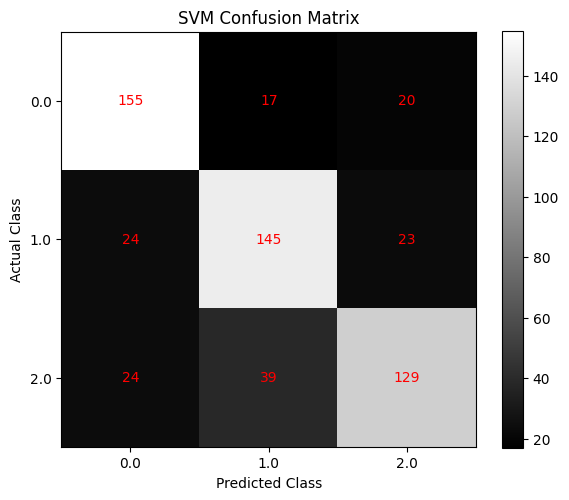

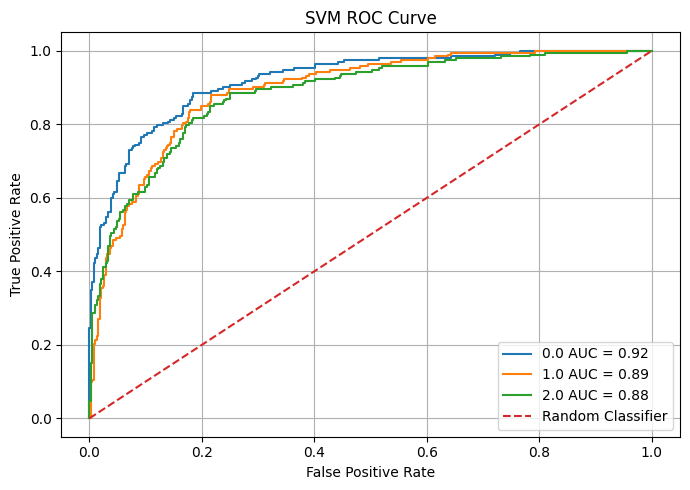


Random_Forest RESULTS
Accuracy  : 80.90%
Precision : 81.07%
Recall    : 80.90%
F1-score  : 80.91%
ROC-AUC   : 0.943

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.86      0.84       192
         1.0       0.76      0.79      0.77       192
         2.0       0.85      0.78      0.81       192

    accuracy                           0.81       576
   macro avg       0.81      0.81      0.81       576
weighted avg       0.81      0.81      0.81       576



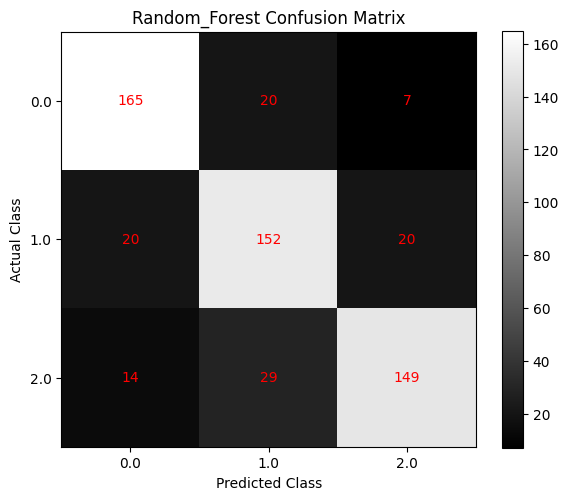

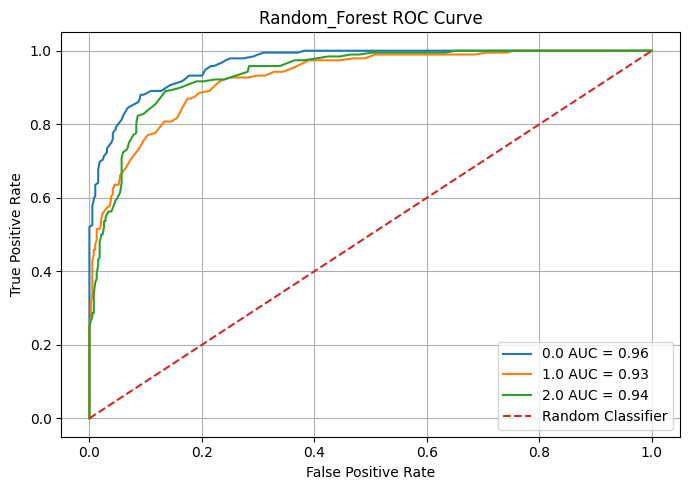


XGBoost RESULTS
Accuracy  : 80.38%
Precision : 80.32%
Recall    : 80.38%
F1-score  : 80.33%
ROC-AUC   : 0.935

Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.86      0.84       192
         1.0       0.78      0.76      0.77       192
         2.0       0.80      0.79      0.80       192

    accuracy                           0.80       576
   macro avg       0.80      0.80      0.80       576
weighted avg       0.80      0.80      0.80       576



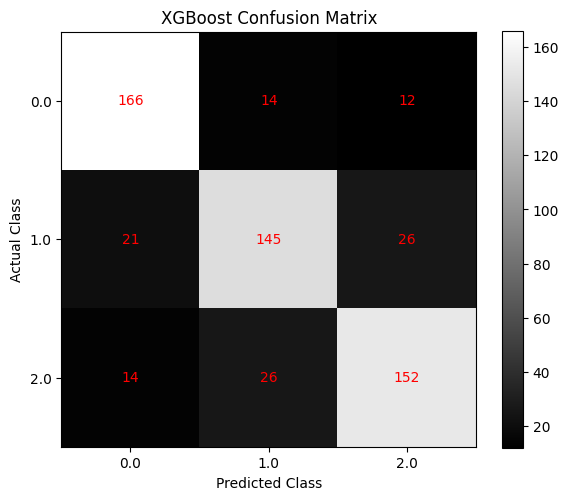

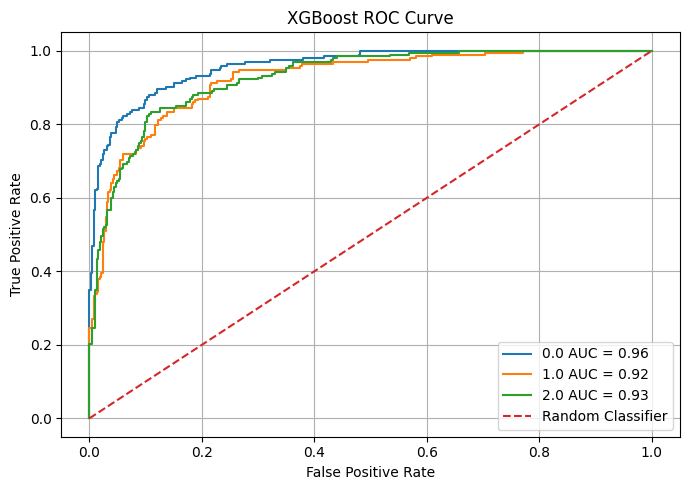


KNN RESULTS
Accuracy  : 71.53%
Precision : 72.09%
Recall    : 71.53%
F1-score  : 71.49%
ROC-AUC   : 0.883

Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.77      0.73       192
         1.0       0.68      0.73      0.71       192
         2.0       0.78      0.65      0.71       192

    accuracy                           0.72       576
   macro avg       0.72      0.72      0.71       576
weighted avg       0.72      0.72      0.71       576



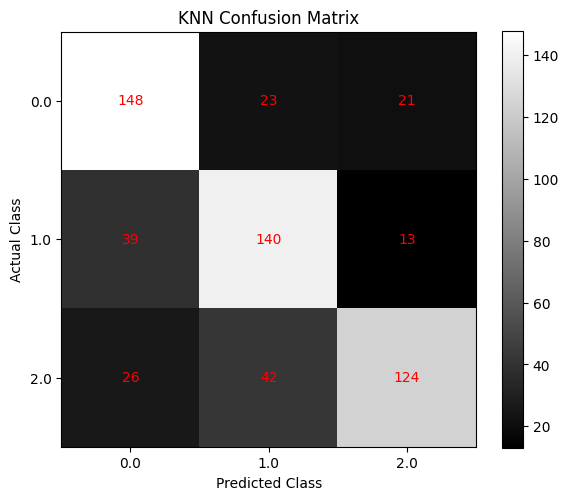

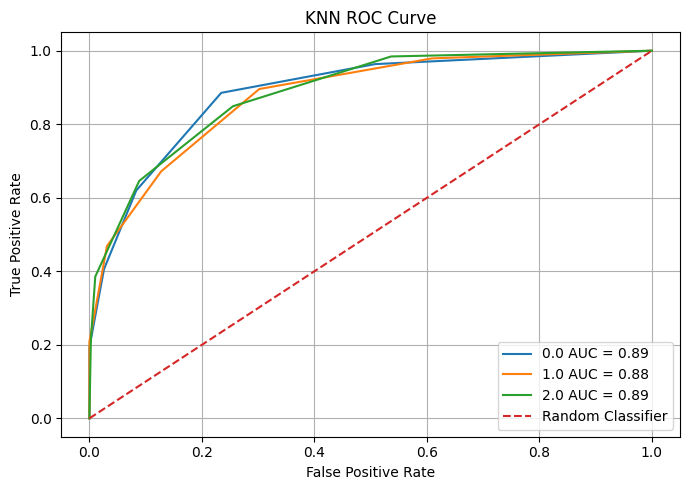


Decision_Tree RESULTS
Accuracy  : 56.60%
Precision : 56.58%
Recall    : 56.60%
F1-score  : 56.58%
ROC-AUC   : 0.674

Classification Report:
              precision    recall  f1-score   support

         0.0       0.63      0.64      0.64       192
         1.0       0.52      0.54      0.53       192
         2.0       0.54      0.52      0.53       192

    accuracy                           0.57       576
   macro avg       0.57      0.57      0.57       576
weighted avg       0.57      0.57      0.57       576



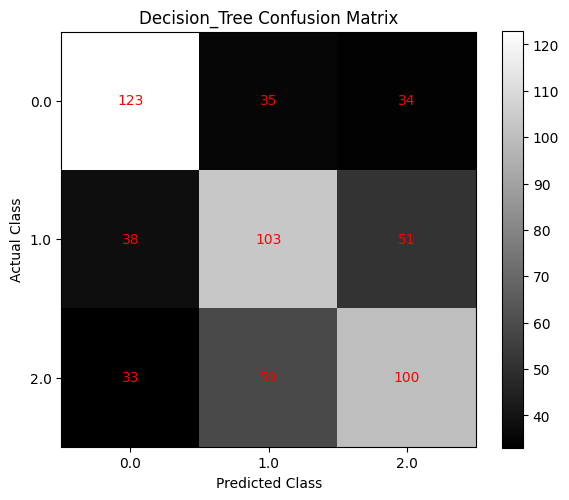

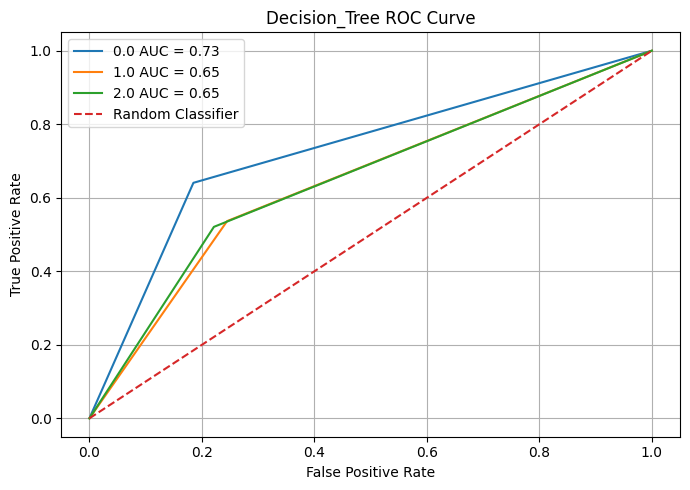


Logistic_Regression RESULTS
Accuracy  : 60.07%
Precision : 60.09%
Recall    : 60.07%
F1-score  : 60.04%
ROC-AUC   : 0.778

Classification Report:
              precision    recall  f1-score   support

         0.0       0.56      0.58      0.57       192
         1.0       0.63      0.66      0.64       192
         2.0       0.61      0.57      0.59       192

    accuracy                           0.60       576
   macro avg       0.60      0.60      0.60       576
weighted avg       0.60      0.60      0.60       576



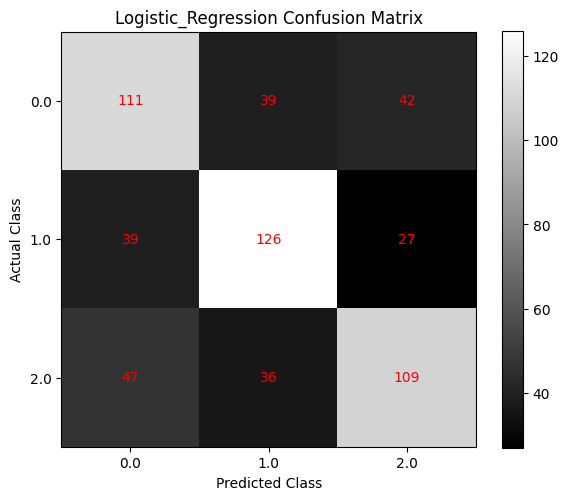

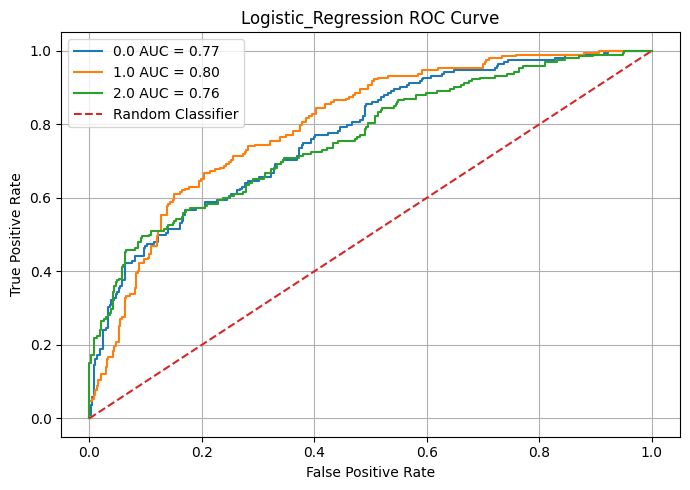

                 Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0                  SVM     74.48      74.50   74.48     74.38    0.899
1        Random_Forest     80.90      81.07   80.90     80.91    0.943
2              XGBoost     80.38      80.32   80.38     80.33    0.935
3                  KNN     71.53      72.09   71.53     71.49    0.883
4        Decision_Tree     56.60      56.58   56.60     56.58    0.674
5  Logistic_Regression     60.07      60.09   60.07     60.04    0.778


In [26]:
# ============================================
# CLASS NAMES
# ============================================

# Get class names from the unique values in y
class_names = [str(c) for c in sorted(y.unique())]

# ============================================
# EVALUATE ALL ML MODELS
# ============================================

results = []

# Evaluate SVM
results.append(
    evaluate_ml_model(
        svm,
        "SVM",
        X_test_scaled,
        y_test,
        class_names
    )
)

# Evaluate Random Forest
results.append(
    evaluate_ml_model(
        rf,
        "Random_Forest",
        X_test,
        y_test,
        class_names
    )
)

# Evaluate XGBoost
results.append(
    evaluate_ml_model(
        xgb,
        "XGBoost",
        X_test,
        y_test,
        class_names
    )
)

# Evaluate KNN
results.append(
    evaluate_ml_model(
        knn,
        "KNN",
        X_test,
        y_test,
        class_names
    )
)

# Evaluate Decision Tree
results.append(
    evaluate_ml_model(
        dt,
        "Decision_Tree",
        X_test,
        y_test,
        class_names
    )
)

# Evaluate Logistic Regression
results.append(
    evaluate_ml_model(
        lr,
        "Logistic_Regression",
        X_test,
        y_test,
        class_names
    )
)

# ============================================
# FINAL RESULT TABLE
# ============================================

results_df = pd.DataFrame(results)

print(results_df)

results_df.to_csv(
    "machine_learning_results.csv",
    index=False
)


**DEEP LEARNING Part**

Input Shape: (50, 1)
Number of Classes: 3


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 50, 64)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 64)    │     66,368 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 50, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 50, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 50, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 50, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 50, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 87,683 (342.51 KB)

 Trainable params: 87,683 (342.51 KB)

...

 Total params: 37,635 (147.01 KB)

 Trainable params: 37,507 (146.51 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.3304 - loss: 1.0979 - val_accuracy: 0.2972 - val_loss: 2.5464
Epoch 2/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3771 - loss: 1.0954 - val_accuracy: 0.2972 - val_loss: 2.0790
Epoch 3/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3576 - loss: 1.0960 - val_accuracy: 0.2972 - val_loss: 1.6824
Epoch 4/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3413 - loss: 1.0937 - val_accuracy: 0.3102 - val_loss: 1.3477
Epoch 5/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3532 - loss: 1.0947 - val_accuracy: 0.3579 - val_loss: 1.2755
Epoch 6/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3413 - loss: 1.0947 - val_accuracy: 0.3492 - val_loss: 1.1383
Epoch 7/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3549 - loss: 1.0935 - val_accuracy: 0.3102 - val_loss: 1.1694
Epoch 8/30
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3673 - loss: 1.0913 - val_accuracy: 0.3514 - v

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

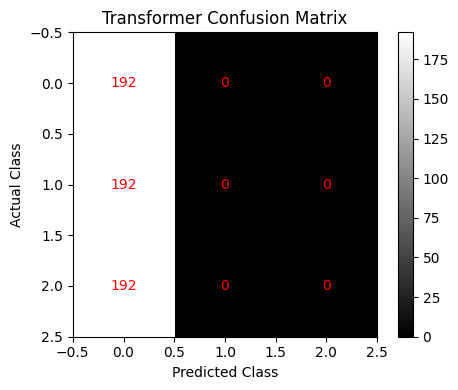

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Attention_Model
Accuracy  : 34.38%
Precision : 44.56%
Recall    : 34.38%
F1-score  : 18.82%
ROC-AUC   : 0.485

Classification Report:
              precision    recall  f1-score   support

         0.0       0.34      1.00      0.50       192
         1.0       1.00      0.03      0.06       192
         2.0       0.00      0.00      0.00       192

    accuracy                           0.34       576
   macro avg       0.45      0.34      0.19       576
weighted avg       0.45      0.34      0.19       576



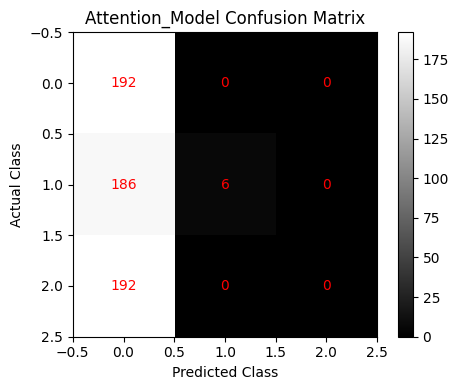

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

GNN_Style_Model
Accuracy  : 34.55%
Precision : 25.52%
Recall    : 34.55%
F1-score  : 20.28%
ROC-AUC   : 0.557

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       192
         1.0       0.34      0.98      0.51       192
         2.0       0.42      0.06      0.10       192

    accuracy                           0.35       576
   macro avg       0.26      0.35      0.20       576
weighted avg       0.26      0.35      0.20       576



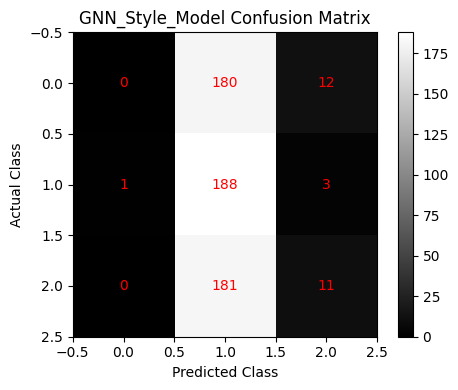


Final Results:
             Model  Accuracy  Precision  Recall  F1-score  ROC-AUC
0      Transformer     33.33      11.11   33.33     16.67    0.500
1  Attention_Model     34.38      44.56   34.38     18.82    0.485
2  GNN_Style_Model     34.55      25.52   34.55     20.28    0.557


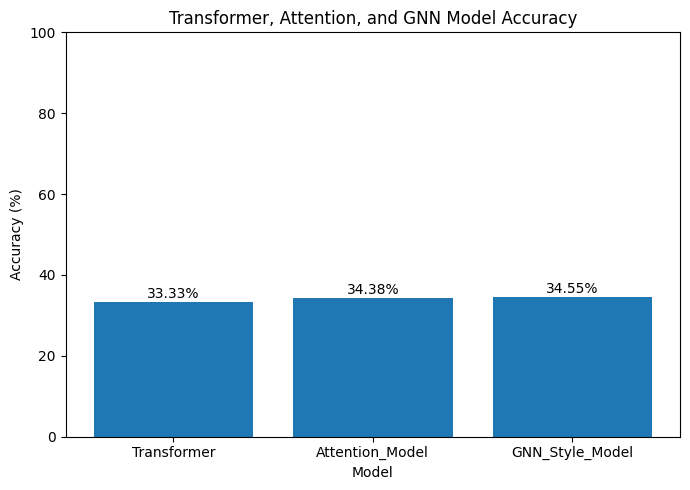

In [27]:
# ==========================================
# TRANSFORMER, ATTENTION, AND GNN MODELS
# FOR EEG CLASSIFICATION
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization,
    MultiHeadAttention, GlobalAveragePooling1D,
    Conv1D, Flatten, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

from sklearn.preprocessing import label_binarize


# ==========================================
# RESHAPE DATA
# ==========================================

# X_train and X_test should already be scaled
# Shape needed: samples, time_steps/features, channels

X_train_dl = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_dl = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

num_classes = len(np.unique(y_train))

y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

input_shape = (X_train_dl.shape[1], 1)

print("Input Shape:", input_shape)
print("Number of Classes:", num_classes)


# ==========================================
# EVALUATION FUNCTION
# ==========================================

def evaluate_deep_model(model, model_name):

    y_prob = model.predict(X_test_dl)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    roc_auc = roc_auc_score(
        y_test_cat,
        y_prob,
        multi_class="ovr",
        average="weighted"
    )

    print("\n" + "="*60)
    print(model_name)
    print("="*60)

    print(f"Accuracy  : {acc*100:.2f}%")
    print(f"Precision : {precision*100:.2f}%")
    print(f"Recall    : {recall*100:.2f}%")
    print(f"F1-score  : {f1*100:.2f}%")
    print(f"ROC-AUC   : {roc_auc:.3f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="gray")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.colorbar()

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i,j], ha="center", va="center", color="red")

    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300)
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": round(acc*100, 2),
        "Precision": round(precision*100, 2),
        "Recall": round(recall*100, 2),
        "F1-score": round(f1*100, 2),
        "ROC-AUC": round(roc_auc, 3)
    }


# ==========================================
# 1. TRANSFORMER MODEL
# ==========================================

def build_transformer_model(input_shape, num_classes):

    inputs = Input(shape=input_shape)

    x = Dense(64)(inputs)

    attention_output = MultiHeadAttention(
        num_heads=4,
        key_dim=64
    )(x, x)

    x = LayerNormalization()(x + attention_output)

    ff = Dense(128, activation="relu")(x)
    ff = Dense(64)(ff)

    x = LayerNormalization()(x + ff)

    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


transformer_model = build_transformer_model(
    input_shape,
    num_classes
)

transformer_model.summary()

transformer_history = transformer_model.fit(
    X_train_dl,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)


# ==========================================
# 2. ATTENTION-BASED MODEL
# ==========================================

def build_attention_model(input_shape, num_classes):

    inputs = Input(shape=input_shape)

    x = Conv1D(64, kernel_size=3, activation="relu", padding="same")(inputs)
    x = BatchNormalization()(x)

    attention = MultiHeadAttention(
        num_heads=2,
        key_dim=32
    )(x, x)

    x = LayerNormalization()(x + attention)

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


attention_model = build_attention_model(
    input_shape,
    num_classes
)

attention_model.summary()

attention_history = attention_model.fit(
    X_train_dl,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)


# ==========================================
# 3. SIMPLE GNN-STYLE MODEL
# ==========================================
# NOTE:
# This is a simplified graph-inspired model.
# For a true GNN, use PyTorch Geometric or Spektral.
# This model treats EEG features/channels as connected nodes.

def build_gnn_style_model(input_shape, num_classes):

    inputs = Input(shape=input_shape)

    # Node feature transformation
    x = Dense(64, activation="relu")(inputs)

    # Graph-style neighborhood aggregation approximation
    x1 = Conv1D(64, kernel_size=3, padding="same", activation="relu")(x)
    x2 = Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)

    x = x1 + x2

    x = BatchNormalization()(x)

    x = GlobalAveragePooling1D()(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


gnn_model = build_gnn_style_model(
    input_shape,
    num_classes
)

gnn_model.summary()

gnn_history = gnn_model.fit(
    X_train_dl,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)


# ==========================================
# EVALUATE ALL MODELS
# ==========================================

results = []

results.append(
    evaluate_deep_model(
        transformer_model,
        "Transformer"
    )
)

results.append(
    evaluate_deep_model(
        attention_model,
        "Attention_Model"
    )
)

results.append(
    evaluate_deep_model(
        gnn_model,
        "GNN_Style_Model"
    )
)

results_df = pd.DataFrame(results)

print("\nFinal Results:")
print(results_df)

results_df.to_csv(
    "transformer_attention_gnn_results.csv",
    index=False
)


# ==========================================
# ACCURACY COMPARISON CHART
# ==========================================

plt.figure(figsize=(7,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.title("Transformer, Attention, and GNN Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, value in enumerate(results_df["Accuracy"]):
    plt.text(i, value + 1, str(value) + "%", ha="center")

plt.tight_layout()
plt.savefig("advanced_models_accuracy_comparison.png", dpi=300)
plt.show()

CSV files found: ['/content/eeg_data/Dataset/user_b.csv', '/content/eeg_data/Dataset/user_a.csv', '/content/eeg_data/Dataset/user_d.csv', '/content/eeg_data/Dataset/user_c.csv']
Merged dataset shape: (11520, 114)
Label column: Class
Classes: [0. 1. 2.]
Feature shape: (11520, 112)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3630 - loss: 1.0958 - val_accuracy: 0.3861 - val_loss: 1.0819
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3979 - loss: 1.0720 - val_accuracy: 0.3948 - val_loss: 1.0604
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4251 - loss: 1.0554 - val_accuracy: 0.4387 - val_loss: 1.0395
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4437 - loss: 1.0345 - val_accuracy: 0.4436 - val_loss: 1.0338
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4655 - loss: 1.0203 - val_accuracy: 0.4642 - val_loss: 1.0170
Epoch 6/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4746 - loss: 1.0056 - val_accuracy: 0.4642 - val_loss: 1.0101
Epoch 7/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4881 - loss: 0.9883 - val_accuracy: 0.4756 - val_loss: 0.9933
Epoch 8/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5038 - loss: 0.9674 - val_accu

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


231/231 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.3371 - loss: 1.0991 - val_accuracy: 0.3460 - val_loss: 1.0968
Epoch 2/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.3626 - loss: 1.0957 - val_accuracy: 0.3433 - val_loss: 1.0967
Epoch 3/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.3563 - loss: 1.0942 - val_accuracy: 0.3601 - val_loss: 1.0935
Epoch 4/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.3668 - loss: 1.0909 - val_accuracy: 0.3644 - val_loss: 1.0946
Epoch 5/50
231/231 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.3695 - loss: 1.0890 - val_accuracy: 0.3595 - val_loss: 1.0900
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

===== CNN Results =====
Accuracy: 0.6775173611111112
Precision: 0.6799319788776782
Recall: 0.6775173611111112
F1-score: 0.6773518647556976
ROC-AUC: 0.8487873783817999

Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.72      0.71       768
         1.0       0.

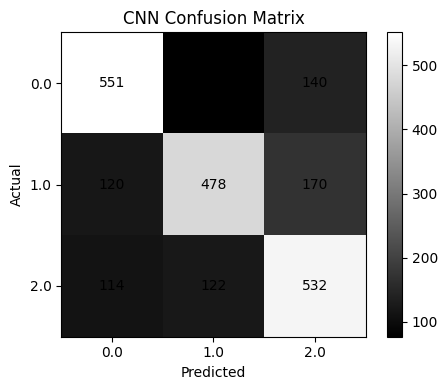

72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step

===== LSTM Results =====
Accuracy: 0.3168402777777778
Precision: 0.31856203180617104
Recall: 0.3168402777777778
F1-score: 0.2936676041498107
ROC-AUC: 0.5158995169180411

Classification Report:
              precision    recall  f1-score   support

         0.0       0.31      0.57      0.40       768
         1.0       0.34      0.22      0.27       768
         2.0       0.30      0.16      0.21       768

    accuracy                           0.32      2304
   macro avg       0.32      0.32      0.29      2304
weighted avg       0.32      0.32      0.29      2304



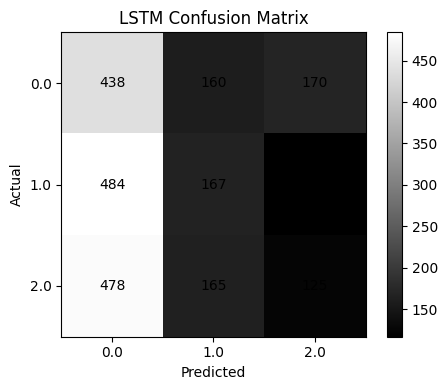


Final CNN + LSTM Results
  Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0   CNN  0.677517   0.679932  0.677517  0.677352  0.848787
1  LSTM  0.316840   0.318562  0.316840  0.293668  0.515900


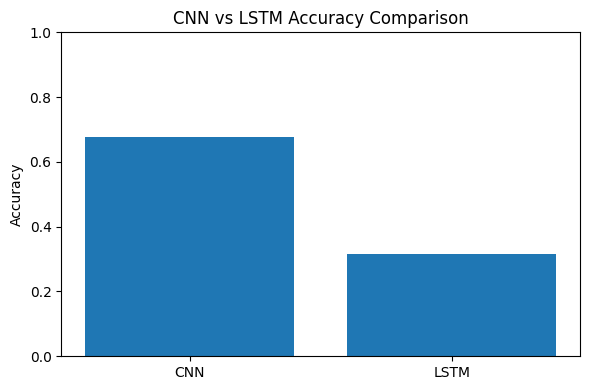

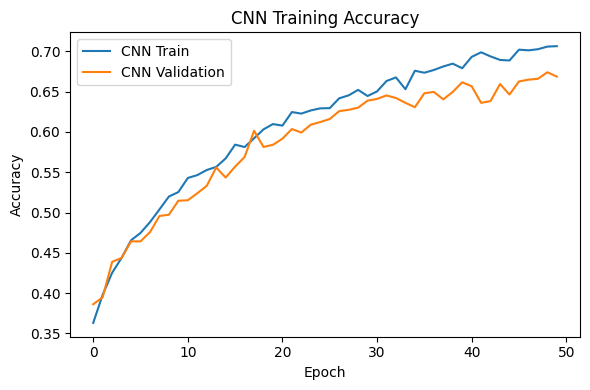

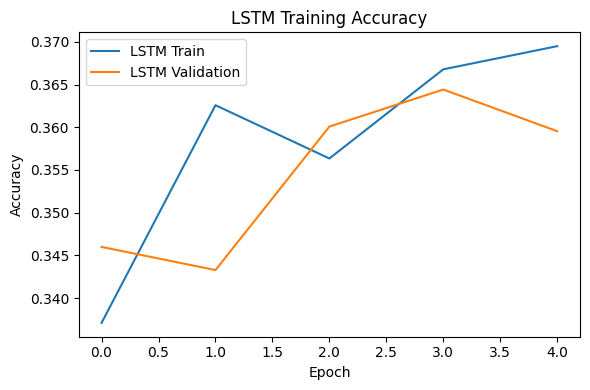

In [ ]:
# =========================
# EEG CNN + LSTM ANALYSIS
# =========================

import zipfile, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# 1. Upload archive.zip in Colab first
zip_path = "/content/archive.zip"
extract_path = "/content/eeg_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

csv_files = glob.glob(extract_path + "/**/*.csv", recursive=True)
print("CSV files found:", csv_files)

# 2. Merge datasets
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df["Subject"] = os.path.basename(file).replace(".csv", "")
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print("Merged dataset shape:", data.shape)

# 3. Detect label column
label_col = "Class" if "Class" in data.columns else data.columns[0]
print("Label column:", label_col)

X = data.drop(columns=[label_col, "Subject"], errors="ignore")
y = data[label_col]

# Keep numeric columns only
X = X.select_dtypes(include=[np.number])

# 4. Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_cat = to_categorical(y_encoded)

print("Classes:", le.classes_)
print("Feature shape:", X.shape)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_encoded
)

# 6. Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for Conv1D/LSTM: samples, timesteps, channels
X_train_dl = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_dl = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

num_classes = y_cat.shape[1]

# =========================
# CNN MODEL
# =========================

cnn_model = Sequential([
    Conv1D(32, kernel_size=3, activation="relu", input_shape=(X_train_dl.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(64, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

cnn_history = cnn_model.fit(
    X_train_dl, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# LSTM MODEL
# =========================

lstm_model = Sequential([
    LSTM(64, input_shape=(X_train_dl.shape[1], 1), return_sequences=False),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_history = lstm_model.fit(
    X_train_dl, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# EVALUATION FUNCTION
# =========================

def evaluate_model(model, model_name):
    y_prob = model.predict(X_test_dl)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    roc = roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted")

    print(f"\n===== {model_name} Results =====")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print("ROC-AUC:", roc)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=[str(c) for c in le.classes_]))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="gray")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.colorbar()
    plt.xticks(range(num_classes), le.classes_)
    plt.yticks(range(num_classes), le.classes_)

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion_matrix.png", dpi=300)
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": roc
    }, y_prob

cnn_results, cnn_prob = evaluate_model(cnn_model, "CNN")
lstm_results, lstm_prob = evaluate_model(lstm_model, "LSTM")

# =========================
# RESULT TABLE
# =========================

results_df = pd.DataFrame([cnn_results, lstm_results])
print("\nFinal CNN + LSTM Results")
print(results_df)

results_df.to_csv("cnn_lstm_results.csv", index=False)

# =========================
# MODEL COMPARISON CHART
# =========================

plt.figure(figsize=(6,4))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.title("CNN vs LSTM Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("cnn_lstm_accuracy_comparison.png", dpi=300)
plt.show()

# =========================
# TRAINING CURVES
# =========================

plt.figure(figsize=(6,4))
plt.plot(cnn_history.history["accuracy"], label="CNN Train")
plt.plot(cnn_history.history["val_accuracy"], label="CNN Validation")
plt.title("CNN Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("cnn_training_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(lstm_history.history["accuracy"], label="LSTM Train")
plt.plot(lstm_history.history["val_accuracy"], label="LSTM Validation")
plt.title("LSTM Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("lstm_training_curve.png", dpi=300)
plt.show()